In [23]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
try:
#     plt.style.use('belle2')
    # plt.style.use('belle2_serif')
    plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# D+ -> (eta' -> pi+ pi- (eta -> gg) ) pi+

In [24]:
file = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC16rd_sigMC/DpEtaPrimePi_Eta_2Photon/260907_loose_v0/'
file += '*.root'
base_filter=' Dp_M>0'
tree = 'gg'
variables = ["__experiment__", "__run__", "__event__",\
             'Dp_M','Dp_isSignal','is_true_Ds','skimhad','gg_EtaPrime_InvM_bf','gg_Eta_InvM_bf']


Dp_gg   = get_pd(file=file , tree=tree, variables=variables ,base_filter=base_filter)
# Dp_gg = Dp_gg.query('Pip_p>0.4')
# Dp_gg = Dp_gg.query('abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8')
# Dp_gg = Dp_gg.query('etapip_Eta_daughterAngle_0_1<1.6')
Dp_gg = Dp_gg.query('skimhad==1')
Dp_gg_true = Dp_gg.query('Dp_isSignal==1')
Dp_gg_false = Dp_gg.query('Dp_isSignal!=1')


Error in <THashList::Delete>: A list is accessing an object (0x55d736fbfd50) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d735366bd0) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d735a5e940) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d735452d10) already deleted (list name = THashList)
Warning in <TFile::Init>: file /share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC16rd_sigMC/DpEtaPrimePi_Eta_2Photon/260907_loose_v0/260907_loose_v0_DpEtaPrimePi_Eta_2Photon_exp017_4S_mDST_e017_00.root probably not closed, trying to recover
Warning in <TFile::Init>: no keys recovered, file has been made a Zombie
Error in <THashList::Delete>: A list is accessing an object (0x55d7363b2870) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d72ebf10a0) already deleted (list nam

In [26]:
# Calculate standard deviation of column 'A'
var = 'Dp_M'
std_dev = Dp_gg_true[var].std()
print(std_dev)

0.013468877881798718


(1.8023556105910064, 1.9370443894089935, 51)


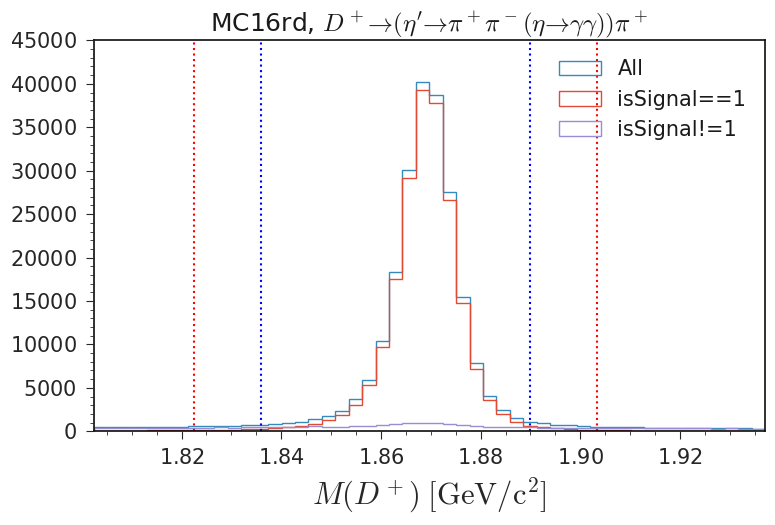

In [27]:
xrange = (1.60,2.1,51)
xrange = (1.8697 - 5*std_dev, 1.8697 + 5*std_dev, 51)
print(xrange)
xm = np.linspace(*xrange)
var = 'Dp_M'
plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to \pi^+ \pi^- (\eta \to \gamma \gamma) ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/gg'
file_path=img_path + '/mc15rd_etaPrimePip_gg_2M_precut_study_Dp_M.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_gg[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_gg_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_gg_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$M(D^+)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.axvline(x=round(1.8697 - 3.5*std_dev, 4),  color='red', linestyle='dotted')
plt.axvline(x=round(1.8697 + 2.5*std_dev, 4),  color='red', linestyle='dotted')

plt.axvline(x=round(1.8697 - 2.5*std_dev, 4),  color='blue', linestyle='dotted')
plt.axvline(x=round(1.8697 + 1.5*std_dev, 4),  color='blue', linestyle='dotted')
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

0.0138545818573007
(0.5062962544280979, 0.5700273309716811, 51)


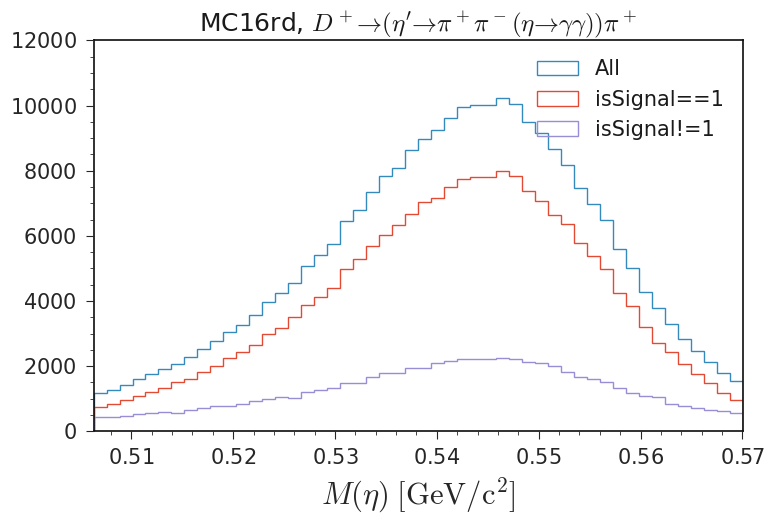

In [39]:
var = 'gg_Eta_InvM_bf'
std_dev = Dp_gg_true[var].std()
print(std_dev)
xrange = ( 0.54786 - 3*std_dev,  0.54786 + 1.6*std_dev, 51)
print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to \pi^+ \pi^- (\eta \to \gamma \gamma) ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/gg'
file_path=img_path + '/mc15rd_etaPrimePip_gg_2M_precut_study_Eta_M.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_gg[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_gg_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_gg_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$M(\eta)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)

plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)

plt.tight_layout()
# plt.savefig(file_path)

0.014721378438736802
(0.9136158646837895, 0.9813342055019788, 51)


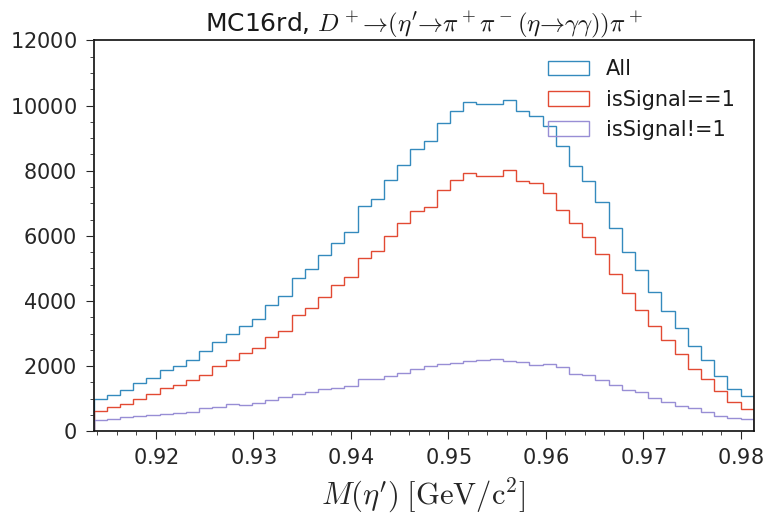

In [41]:
var = 'gg_EtaPrime_InvM_bf'
std_dev = Dp_gg_true[var].std()
print(std_dev)
xrange = ( 0.95778 - 3*std_dev,  0.95778 + 1.6*std_dev, 51)
print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to \pi^+ \pi^- (\eta \to \gamma \gamma) ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/gg'
file_path=img_path + '/mc15rd_etaPrimePip_gg_2M_precut_study_EtaPrime_M.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_gg[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_gg_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_gg_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$M(\eta^\prime)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)

plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)

plt.tight_layout()
# plt.savefig(file_path)

# D+ -> (eta' -> pi+ pi- (eta -> pi+ pi- pi0) ) pi+

In [154]:
file = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC16rd_sigMC/DpEtaPrimePi_Eta_3Pion/260907_loose_v0/'
file += '*.root'
# base_filter=' Dp_M>0 and pipipi_Eta_InvM_bf > 0.54 and pipipi_Eta_InvM_bf < 0.56 and pipipi_EtaPrime_InvM_bf > 0.945 and pipipi_EtaPrime_InvM_bf<0.97'
base_filter=' Dp_M>0'
tree = 'pipipi'
variables = ["__experiment__", "__run__", "__event__",\
             'Dp_M','Dp_isSignal','is_true_Ds','skimhad','pipipi_EtaPrime_InvM_bf','pipipi_Eta_InvM_bf','eta_pi0_gamma1_E','eta_pi0_gamma2_E','Eta_p']


Dp_pipipi   = get_pd(file=file , tree=tree, variables=variables ,base_filter=base_filter)
# Dp_gg = Dp_gg.query('Pip_p>0.4')
# Dp_gg = Dp_gg.query('abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8')
# Dp_gg = Dp_gg.query('etapip_Eta_daughterAngle_0_1<1.6')
Dp_pipipi = Dp_pipipi.query('skimhad==1')
Dp_pipipi_true = Dp_pipipi.query('Dp_isSignal==1')
Dp_pipipi_false = Dp_pipipi.query('Dp_isSignal!=1')


Warning in <TFile::Init>: file /share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC16rd_sigMC/DpEtaPrimePi_Eta_3Pion/260907_loose_v0/260907_loose_v0_DpEtaPrimePi_Eta_3Pion_exp012_4S_mDST_e012_00.root probably not closed, trying to recover
Warning in <TFile::Init>: no keys recovered, file has been made a Zombie
Error in <THashList::Delete>: A list is accessing an object (0x55d7b2159720) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d712bf0b00) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7b26e9210) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d78fa348a0) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7c073eea0) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7affb1710) already deleted (list name = 

In [155]:
# Calculate standard deviation of column 'A'
var = 'Dp_M'
std_dev = Dp_pipipi_true[var].std()
print(std_dev)

0.013277332637161974


(1.80331333681419, 1.9360866631858098, 51)


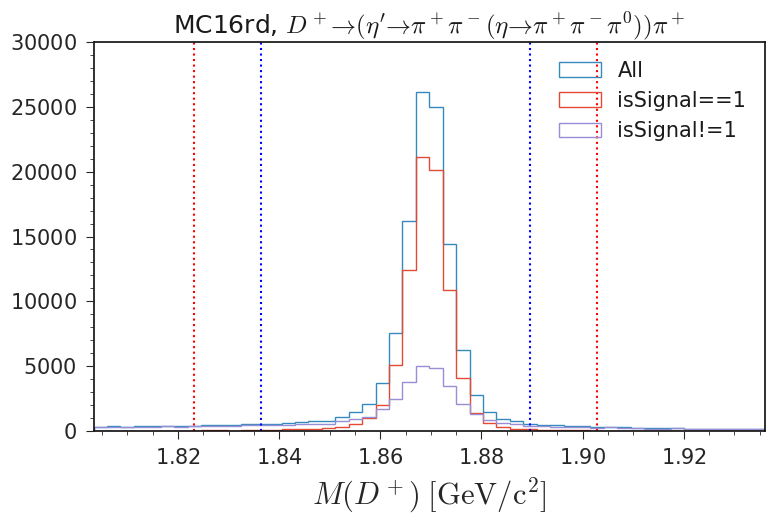

In [156]:
xrange = (1.60,2.1,51)
xrange = (1.8697 - 5*std_dev, 1.8697 + 5*std_dev, 51)
print(xrange)
xm = np.linspace(*xrange)
var = 'Dp_M'
plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to \pi^+ \pi^- (\eta \to \pi^+ \pi^- \pi^0) ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/pipipi'
file_path=img_path + '/mc15rd_etaPrimePip_pipipi_2M_precut_study_Dp_M.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_pipipi[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$M(D^+)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.axvline(x=round(1.8697 - 3.5*std_dev, 4),  color='red', linestyle='dotted')
plt.axvline(x=round(1.8697 + 2.5*std_dev, 4),  color='red', linestyle='dotted')

plt.axvline(x=round(1.8697 - 2.5*std_dev, 4),  color='blue', linestyle='dotted')
plt.axvline(x=round(1.8697 + 1.5*std_dev, 4),  color='blue', linestyle='dotted')
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

In [157]:
Dp_pipipi

,__experiment__,__run__,__event__,Dp_M,Dp_isSignal,is_true_Ds,skimhad,pipipi_EtaPrime_InvM_bf,pipipi_Eta_InvM_bf,eta_pi0_gamma1_E,eta_pi0_gamma2_E,Eta_p
0,12,4022,10,1.872157,1.0,False,1.0,0.957561,0.547097,0.196189,0.203244,1.093053
1,12,4022,13,1.869806,1.0,False,1.0,0.954293,0.545937,0.400336,0.079112,0.896101
2,12,4022,13,1.957883,0.0,False,1.0,0.972818,0.545937,0.398688,0.080123,0.895381
3,12,4023,9,1.872699,1.0,False,1.0,0.958641,0.547749,0.327314,0.180419,1.106757
4,12,4023,13,1.856385,0.0,False,1.0,0.951832,0.535430,0.126265,0.102422,0.902473
...,...,...,...,...,...,...,...,...,...,...,...,...
146967,35,2501,118,1.867802,1.0,False,1.0,0.958245,0.545168,0.110922,0.229475,0.910375
146968,35,2501,122,1.873876,1.0,False,1.0,0.960519,0.545240,0.214046,0.168371,1.396187
146969,35,2501,149,1.865552,0.0,False,1.0,0.963955,0.550953,0.064344,0.308342,1.164986
146970,35,2501,149,1.866606,1.0,False,1.0,0.963955,0.553467,0.064985,0.305941,0.950889


0.003766865393438158
(0.5327925384262474, 0.5629274615737526, 51)


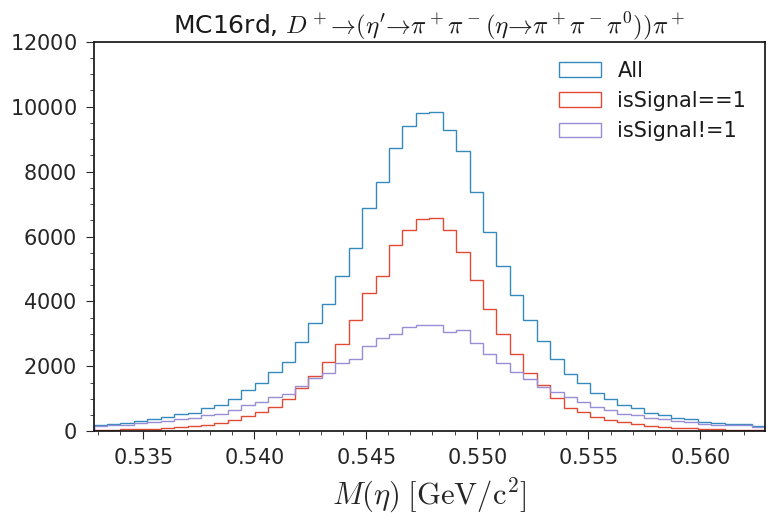

In [158]:
var = 'pipipi_Eta_InvM_bf'
std_dev = Dp_pipipi_true[var].std()
print(std_dev)
xrange = ( 0.54786 - 2.5*std_dev,  0.54786 + 1.6*std_dev, 51)
xrange = ( 0.54786 - 4*std_dev,  0.54786 + 4*std_dev, 51)

print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to \pi^+ \pi^- (\eta \to \pi^+ \pi^- \pi^0) ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/pipipi'
file_path=img_path + '/mc15rd_etaPrimePip_pipipi_2M_precut_study_Eta_M.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_pipipi[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$M(\eta)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

0.004915548558536745
(0.9445080188919508, 0.9676110971170735, 51)


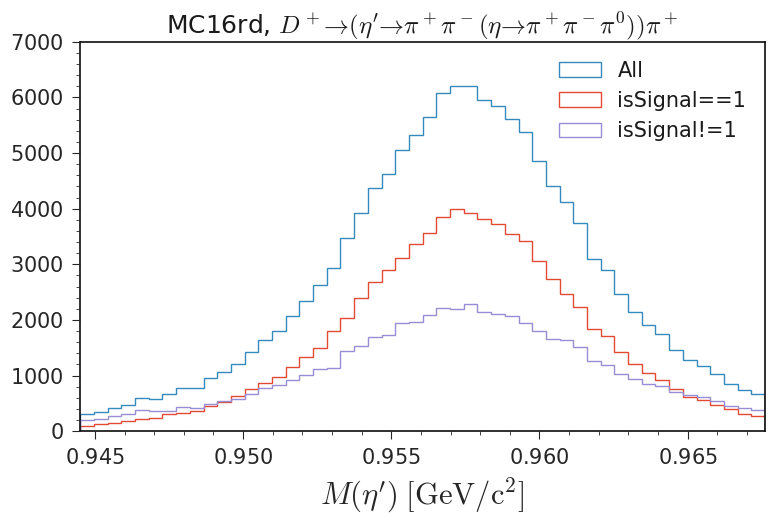

In [159]:
var = 'pipipi_EtaPrime_InvM_bf'
std_dev = Dp_pipipi_true[var].std()
print(std_dev)
xrange = ( 0.95778 - 2.7*std_dev,  0.95778 + 2*std_dev, 51)

print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to \pi^+ \pi^- (\eta \to \pi^+ \pi^- \pi^0) ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/pipipi'
file_path=img_path + '/mc15rd_etaPrimePip_pipipi_2M_precut_study_Eta_M.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_pipipi[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$M(\eta^\prime)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

0.18580943925507953
(0.055, 1.2, 51)


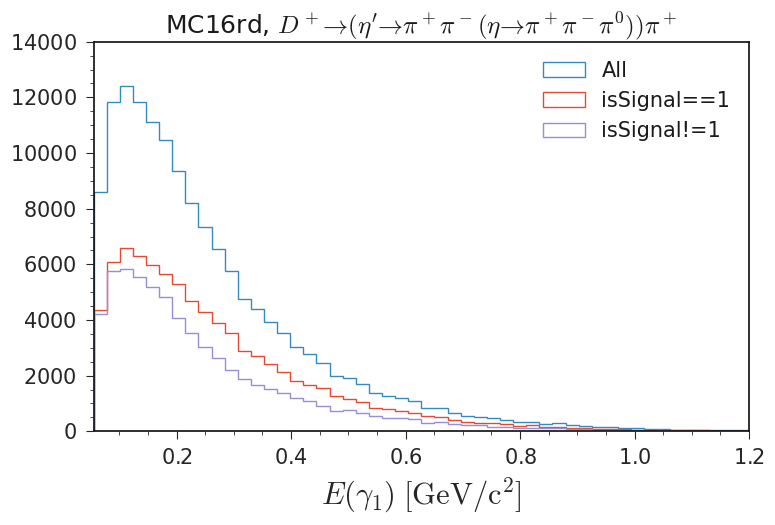

In [160]:
var = 'eta_pi0_gamma1_E'
std_dev = Dp_pipipi_true[var].std()
print(std_dev)
xrange = ( 0.055,  1.2, 51)

print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to \pi^+ \pi^- (\eta \to \pi^+ \pi^- \pi^0) ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/pipipi'
file_path=img_path + '/mc15rd_etaPrimePip_pipipi_2M_precut_study_gamma1_E.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_pipipi[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$E(\gamma_1)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

0.1923660933246526
(0.055, 1.2, 51)


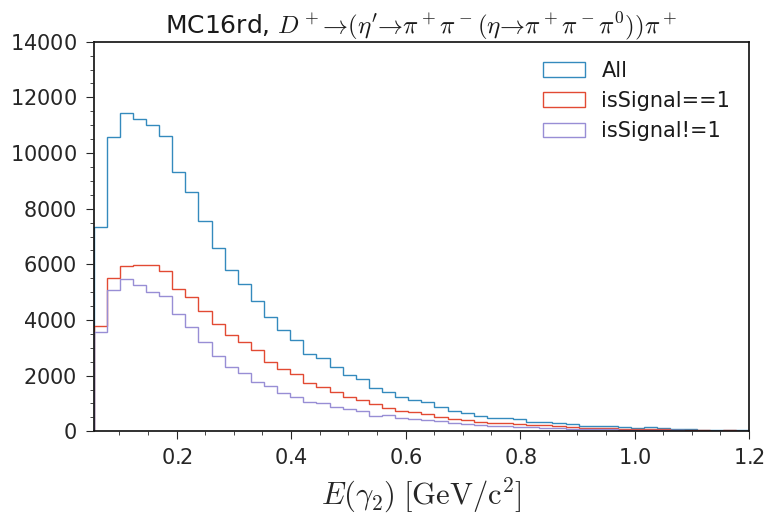

In [161]:
var = 'eta_pi0_gamma2_E'
std_dev = Dp_pipipi_true[var].std()
print(std_dev)
xrange = ( 0.055,  1.2, 51)

print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to \pi^+ \pi^- (\eta \to \pi^+ \pi^- \pi^0) ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/pipipi'
file_path=img_path + '/mc15rd_etaPrimePip_pipipi_2M_precut_study_gamma2_E.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_pipipi[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$E(\gamma_2)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

0.5706697422130891
(0, 3, 51)


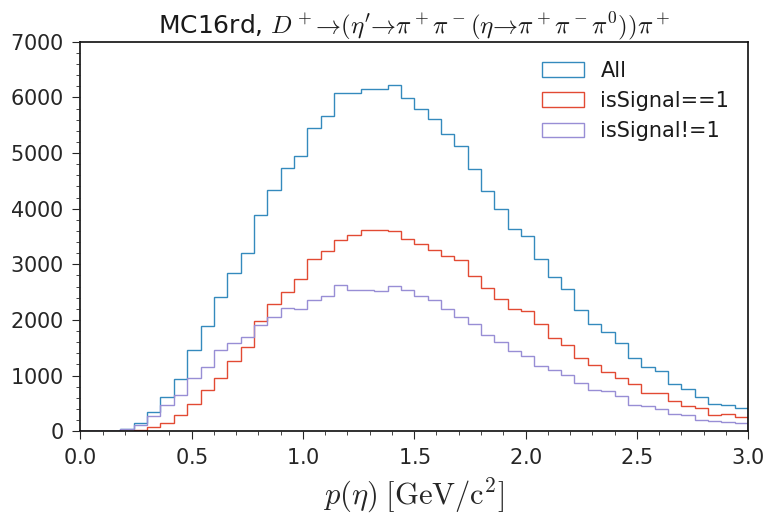

In [163]:
var = 'Eta_p'
std_dev = Dp_pipipi_true[var].std()
print(std_dev)
xrange = ( 0,  3, 51)

print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to \pi^+ \pi^- (\eta \to \pi^+ \pi^- \pi^0) ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/pipipi'
file_path=img_path + '/mc15rd_etaPrimePip_pipipi_2M_precut_study_Eta_p.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_pipipi[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_pipipi_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$p(\eta)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

# D+ -> (eta' -> rho gamma ) pi+

In [164]:
file = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC16rd_sigMC/DpEtaPrimePi_Rhogamma/260907_loose_v0/'
file += '*.root'
base_filter=' Dp_M>0'
# base_filter=' Dp_M>0 & rhog_gamma_E>0.2'
tree = 'rhog'
variables = ["__experiment__", "__run__", "__event__",\
             'Dp_M','Dp_isSignal','is_true_Ds','skimhad','rhog_EtaPrime_InvM_bf', 'rhog_rho0_InvM_bf','rhog_gamma_E','rho_p']


Dp_rhog   = get_pd(file=file , tree=tree, variables=variables ,base_filter=base_filter)
Dp_rhog = Dp_rhog.query('skimhad==1')
Dp_rhog_true = Dp_rhog.query('Dp_isSignal==1')
Dp_rhog_false = Dp_rhog.query('Dp_isSignal!=1')


Error in <THashList::Delete>: A list is accessing an object (0x55d7c7406e80) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7c7a782a0) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7c7fdb1f0) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7c8e71360) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7c90ba990) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7c96c5ee0) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7c87ef930) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d7ca877970) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x5

In [165]:
# Calculate standard deviation of column 'A'
var = 'Dp_M'
std_dev = Dp_rhog_true[var].std()
print(std_dev)

0.012798486640170666


(1.8057075667991467, 1.9336924332008532, 51)


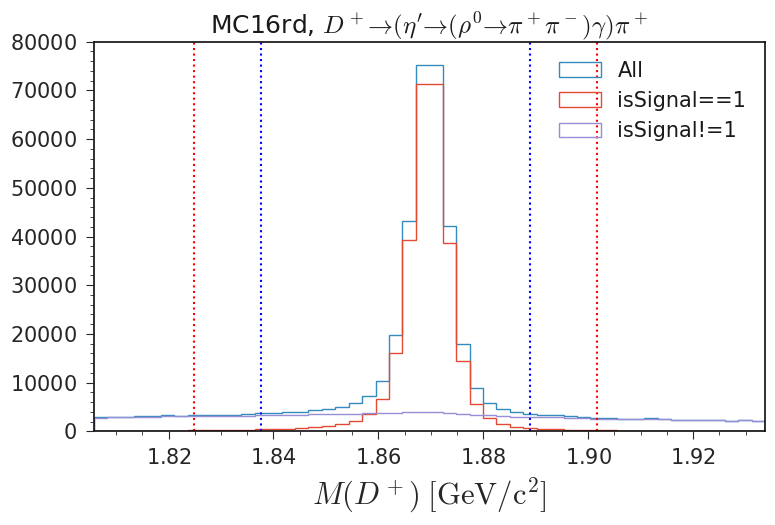

In [166]:
xrange = (1.60,2.1,51)
xrange = (1.8697 - 5*std_dev, 1.8697 + 5*std_dev, 51)
print(xrange)
xm = np.linspace(*xrange)
var = 'Dp_M'
plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to (\rho^0 \to \pi^+ \pi^-) \gamma ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/rhog'
file_path=img_path + '/mc15rd_etaPrimePip_rhog_2M_precut_study_Dp_M.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_rhog[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$M(D^+)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.axvline(x=round(1.8697 - 3.5*std_dev, 4),  color='red', linestyle='dotted')
plt.axvline(x=round(1.8697 + 2.5*std_dev, 4),  color='red', linestyle='dotted')

plt.axvline(x=round(1.8697 - 2.5*std_dev, 4),  color='blue', linestyle='dotted')
plt.axvline(x=round(1.8697 + 1.5*std_dev, 4),  color='blue', linestyle='dotted')
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

0.08330385936579401
(0.5420091937757767, 0.9085461749852703, 51)


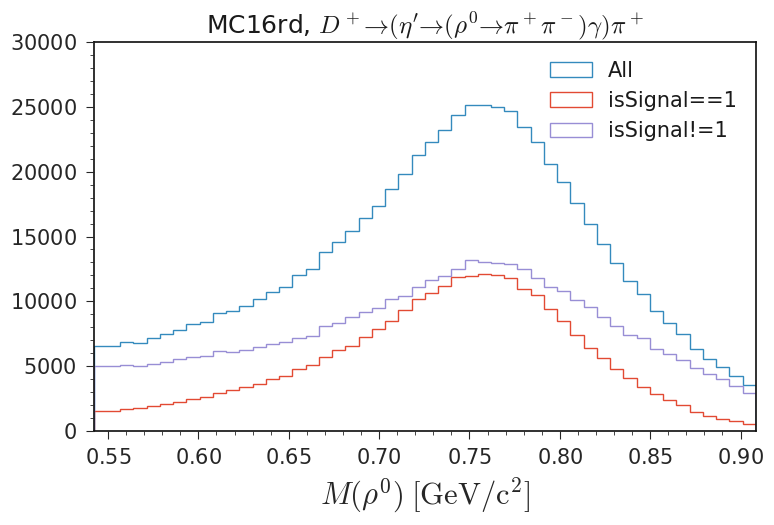

In [167]:
var = 'rhog_rho0_InvM_bf'
std_dev = Dp_rhog_true[var].std()
print(std_dev)
xrange = ( 0.77526 - 2.8*std_dev, 0.77526+ 1.6*std_dev, 51)
print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to (\rho^0 \to \pi^+ \pi^-) \gamma ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/rhog'
file_path=img_path + '/mc15rd_etaPrimePip_rhog_2M_precut_study_Rho_M.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_rhog[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$M(\rho^0)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

0.011937111897207756
(0.9279372202569806, 0.9768793790355323, 51)


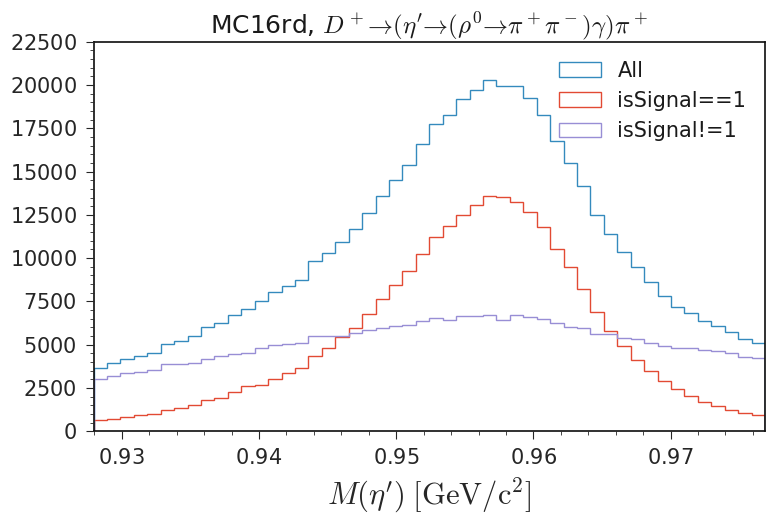

In [168]:
var = 'rhog_EtaPrime_InvM_bf'
std_dev = Dp_rhog_true[var].std()
print(std_dev)
xrange = ( 0.95778 - 2.5*std_dev, 0.95778+ 1.6*std_dev, 51)
print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to (\rho^0 \to \pi^+ \pi^-) \gamma ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/rhog'
file_path=img_path + '/mc15rd_etaPrimePip_rhog_2M_precut_study_EtaPrime_M.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_rhog[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$M(\eta^\prime)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

0.37211628591319795
(0.2, 2, 51)


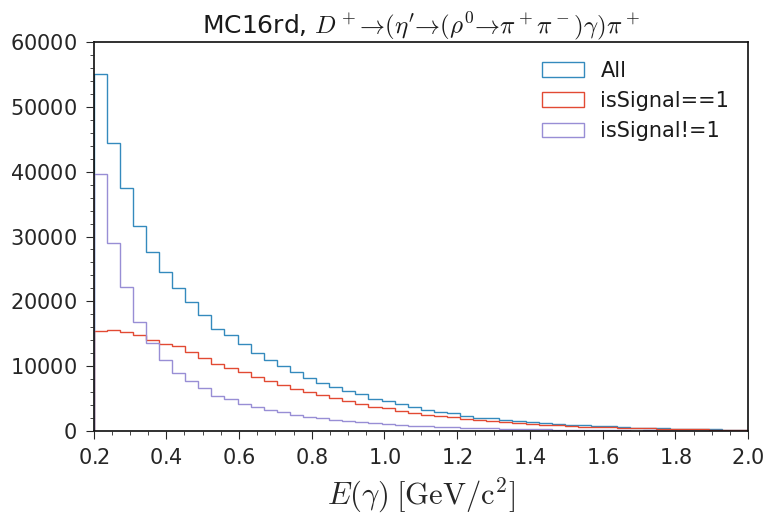

In [169]:
var = 'rhog_gamma_E'
std_dev = Dp_rhog_true[var].std()
print(std_dev)
xrange = ( 0.2,  2, 51)
print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to (\rho^0 \to \pi^+ \pi^-) \gamma ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/rhog'
file_path=img_path + '/mc15rd_etaPrimePip_rhog_2M_precut_study_gamma_E.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_rhog[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$E(\gamma)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)

0.7927121059337058
(0, 4.5, 51)


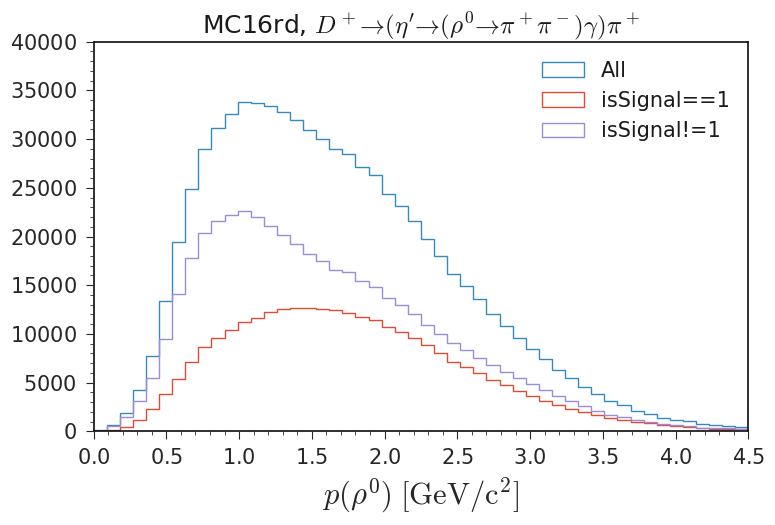

In [170]:
var = 'rho_p'
std_dev = Dp_rhog_true[var].std()
print(std_dev)
xrange = ( 0,  4.5, 51)
print(xrange)
xm = np.linspace(*xrange)

plot_title = r'MC16rd, $D^+ \to (\eta^\prime \to (\rho^0 \to \pi^+ \pi^-) \gamma ) \pi^+$'
img_path='/media/jykim/T7/saved_plots/DRAW/etaPrimePip/MC16rd_sig/rhog'
file_path=img_path + '/mc15rd_etaPrimePip_rhog_2M_precut_study_rho_p.png'

# Extract the directory from the file path
directory = os.path.dirname(file_path)
if not os.path.exists(directory):
    os.makedirs(directory)

plt.hist(Dp_rhog[var], label='All',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_true[var], label='isSignal==1',bins=xm,  histtype='step') 
plt.hist(Dp_rhog_false[var], label='isSignal!=1',bins=xm,  histtype='step') 

ax = plt.gca()
ax.set_xlim(xrange[0],xrange[1])   
xlabel = r'$p(\rho^0)\; [\mathrm{GeV/c^2}] $'
ax.set_xlabel(xlabel)
plt.title(plot_title)
plt.legend(loc='upper right')
# plt.xlim(1.8697 - 3.5*std_dev, 1.8697 + 2.5*std_dev)
plt.tight_layout()
# plt.savefig(file_path)